In [1]:
import warnings


In [2]:
warnings.filterwarnings("ignore")


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

In [5]:
titanic_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

In [6]:
X_titanic = titanic_df[titanic_features]
y_titanic = titanic_df['Survived']


In [7]:
X_titanic['Age'] = X_titanic['Age'].fillna(
    X_titanic['Age'].median()
)

In [8]:
X_titanic['Embarked'] = X_titanic['Embarked'].fillna(
    X_titanic['Embarked'].mode()[0]
)

In [9]:
X_titanic = pd.get_dummies(
    X_titanic,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

In [10]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)


In [11]:
print("Titanic Classification Training Set Shape:", X_train_c.shape)
print("Titanic Classification Test Set Shape:", X_test_c.shape)

Titanic Classification Training Set Shape: (712, 8)
Titanic Classification Test Set Shape: (179, 8)


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [13]:
tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [14]:

tree_clf.fit(X_train_c, y_train_c)

clf_preds = tree_clf.predict(X_test_c)

In [15]:
print(
    f"Decision Tree Classifier Test Accuracy: "
    f"{accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n"
)

Decision Tree Classifier Test Accuracy: 78.77%



In [16]:
print("--- Classification Report ---")

print(
    classification_report(
        y_test_c,
        clf_preds,
        target_names=['Not Survived (0)', 'Survived (1)']
    )
)


--- Classification Report ---
                  precision    recall  f1-score   support

Not Survived (0)       0.77      0.94      0.84       110
    Survived (1)       0.84      0.55      0.67        69

        accuracy                           0.79       179
       macro avg       0.81      0.74      0.76       179
    weighted avg       0.80      0.79      0.78       179



In [17]:
import matplotlib.pyplot as plt

In [18]:
from sklearn.tree import plot_tree

In [19]:
plt.figure(figsize=(15, 8))


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

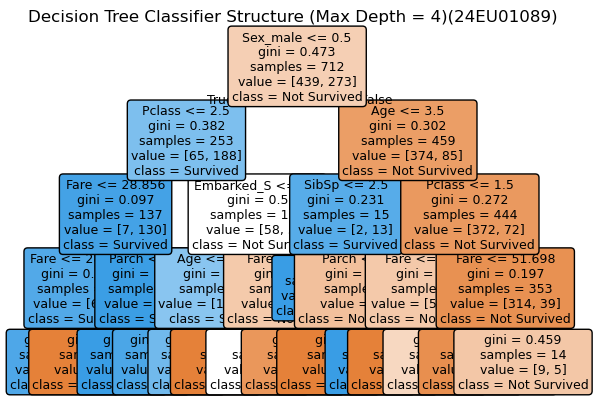

In [50]:
plot_tree(
    tree_clf,
    feature_names=X_titanic.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(
    "Decision Tree Classifier Structure (Max Depth = 4)(24EU01089)"
)
plt.show()

In [21]:
import warnings

In [22]:
warnings.filterwarnings("ignore")

In [23]:
from sklearn.datasets import fetch_california_housing

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
california = fetch_california_housing()

In [26]:
california_df = pd.DataFrame(
    california.data,
    columns=california.feature_names
)

In [27]:
california_df['MedHouseVal'] = california.target

In [28]:
california_features = california.feature_names

In [29]:
X_california = california_df[california_features]

In [30]:
y_california = california_df['MedHouseVal']

In [31]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_california,
    y_california,
    test_size=0.20,
    random_state=42
)

In [32]:
print(
    "California Housing Regression Training Set Shape:",
    X_train_r.shape
)

print(
    "California Housing Regression Test Set Shape:",
    X_test_r.shape
)

California Housing Regression Training Set Shape: (16512, 8)
California Housing Regression Test Set Shape: (4128, 8)


In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler_r = StandardScaler()

In [35]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [36]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [37]:
from sklearn.tree import DecisionTreeRegressor

In [38]:
tree_reg = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [39]:
tree_reg.fit(
    X_train_r_scaled,
    y_train_r
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [40]:
print(
    "Decision Tree Regressor trained successfully. "
    "Max Depth set to 5."
)

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [41]:
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
import numpy as np

In [43]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [44]:
mse = mean_squared_error(y_test_r, reg_preds)

In [45]:
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, reg_preds)

In [46]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Coefficient of Determination: {r2:.4f}")

Mean Squared Error (MSE): 0.5245
Root Mean Squared Error (RMSE): 0.7242
R2 Coefficient of Determination: 0.5997


In [47]:
import matplotlib.pyplot as plt

In [48]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

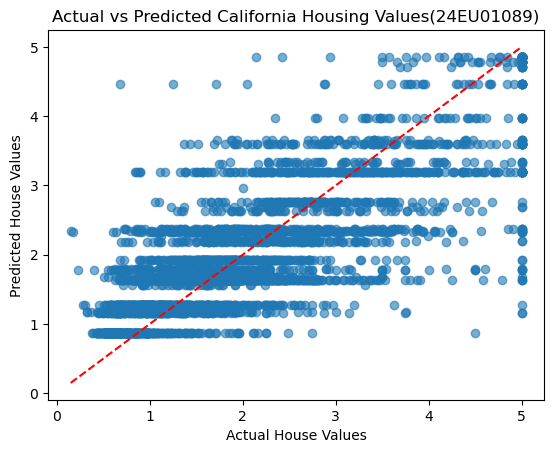

In [51]:
plt.scatter(
    y_test_r,
    reg_preds,
    alpha=0.6
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")

plt.title(
    "Actual vs Predicted California Housing Values(24EU01089)"
)

# Reference line
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()],
    'r--'
)

plt.show()